In [7]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')



# ── 1. Load ──────────────────────────────────────────────────
df = pd.read_csv("/kaggle/input/datasets/duckyyyrobinson/transaction2/synthetic_200k_labels.csv")
print(df.columns)
print(df.info)
print(df.values)


Index(['Id', 'So the', 'Loai giao dich', 'Trang thai', 'So tien',
       'Don vi tien te', 'So du', 'Phi', 'Ty gia', 'Noi dung chuyen khoan',
       'Thoi gian', 'Ly do tu choi', 'matched_txn_id', 'from', 'subject',
       'kind', 'user_account', 'label'],
      dtype='object')
<bound method DataFrame.info of                   Id            So the          Loai giao dich Trang thai  \
0        WLFJR-00001  8891700002233145             CARD_REFUND    SUCCESS   
1        WLFJR-00002  8891700002233145             CARD_TOP_UP    SUCCESS   
2        WLFJR-00003          ****0104            CARD_PAYMENT    SUCCESS   
3        WLFJR-00004          ****0103             CARD_TOP_UP    SUCCESS   
4        WLFJR-00005               NaN             CARD_TOP_UP    SUCCESS   
...              ...               ...                     ...        ...   
199995  WLFJR-199996          ****0102    WALLET_WITHDRAW_BANK    SUCCESS   
199996  WLFJR-199997          ****0103  TOPUP_WALLET_FROM_CARD    SUCCESS

In [8]:
# ════════════════════════════════════════════════════════════════════
# CELL 1: SETUP + ISOLATION FOREST (UPDATED)
# ════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error

# ── 1. Load ──────────────────────────────────────────────────
df = pd.read_csv("/kaggle/input/datasets/duckyyyrobinson/transaction2/synthetic_200k_labels.csv")

# Rename columns để dùng tiếng Anh
df.columns = [
    'Id', 'So_the', 'Loai_giao_dich', 'Trang_thai', 'So_tien',
    'Don_vi_tien_te', 'So_du', 'Phi', 'Ty_gia', 'Noi_dung_chuyen_khoan',
    'Thoi_gian', 'Ly_do_tu_choi', 'matched_txn_id', 'email_from', 
    'email_subject', 'email_kind', 'user_account', 'label'
]

print(f"Loaded {len(df):,} transactions")
print(f"Columns: {list(df.columns)}")

# ── 2. Feature Engineering ────────────────────────────────────
df['Thoi_gian'] = pd.to_datetime(df['Thoi_gian'])
df['gio'] = df['Thoi_gian'].dt.hour
df['ngay_trong_tuan'] = df['Thoi_gian'].dt.dayofweek
df['ngay_trong_thang'] = df['Thoi_gian'].dt.day
df['thang'] = df['Thoi_gian'].dt.month

# Aggregate features
df['tan_suat_the'] = df.groupby(['So_the', df['Thoi_gian'].dt.date])['Id'].transform('count')
df['tb_tien_the'] = df.groupby('So_the')['So_tien'].transform('mean')
df['do_lech_tien'] = abs(df['So_tien'] - df['tb_tien_the']) / (df['tb_tien_the'] + 1)
df['ti_le_du_tien'] = df['So_du'] / (df['So_tien'] + 1)

# ── 3. Encode ─────────────────────────────────────────────────
le_loai = LabelEncoder()
le_ck = LabelEncoder()
df['loai_encoded'] = le_loai.fit_transform(df['Loai_giao_dich'])
df['ck_encoded'] = le_ck.fit_transform(df['Noi_dung_chuyen_khoan'].fillna('-').astype(str))

# ── 4. Features & Scale ────────────────────────────────────────
feature_cols = [
    'So_tien', 'Phi', 'Ty_gia', 'loai_encoded', 'ck_encoded',
    'gio', 'ngay_trong_tuan', 'ngay_trong_thang', 'thang',
    'tan_suat_the', 'do_lech_tien', 'ti_le_du_tien',
]
X = df[feature_cols].fillna(0).values.astype(np.float32)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 5. Isolation Forest ─────────────────────────────────────
print("\nTraining Isolation Forest...")
iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=42, n_jobs=-1)
df['outlier'] = iso.fit_predict(X_scaled)
df['anomaly_score'] = iso.decision_function(X_scaled)
print(f"Done! Outliers: {(df['outlier'] == -1).sum()}")

# ── 6. Feature Weights ───────────────────────────────────────
print("Calculating weights...")
importances_mean = np.zeros(len(feature_cols))
SAMPLE_SIZE = 10000
sample_idx = np.random.choice(len(X_scaled), size=SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]
baseline_scores = iso.decision_function(X_sample).tolist()

for i in range(len(feature_cols)):
    scores = []
    for _ in range(2):
        X_perm = X_sample.copy()
        np.random.shuffle(X_perm[:, i])
        perm_scores = iso.decision_function(X_perm).tolist()
        scores.append(mean_squared_error(baseline_scores, perm_scores))
    importances_mean[i] = np.mean(scores)

weights = np.array([importances_mean[feature_cols.index(f)] for f in feature_cols])
weights_min, weights_max = weights.min(), weights.max()
weights = 1 + 9 * (weights - weights_min) / (weights_max - weights_min + 1e-10)
weights = np.clip(weights, 1, 10).astype(np.float32)

print("\nFeature Weights:")
for f, w in zip(feature_cols, weights):
    print(f"   {f:<20} {w:.2f}")

# Weighted IF
X_weighted = X_scaled * weights.reshape(1, -1)
print("\nTraining Weighted IF...")
iso_w = IsolationForest(n_estimators=200, contamination=0.01, random_state=42, n_jobs=-1)
df['outlier_weighted'] = iso_w.fit_predict(X_weighted)
df['anomaly_score_weighted'] = iso_w.decision_function(X_weighted)
print(f"Done! Outliers: {(df['outlier_weighted'] == -1).sum()}")

Loaded 200,000 transactions
Columns: ['Id', 'So_the', 'Loai_giao_dich', 'Trang_thai', 'So_tien', 'Don_vi_tien_te', 'So_du', 'Phi', 'Ty_gia', 'Noi_dung_chuyen_khoan', 'Thoi_gian', 'Ly_do_tu_choi', 'matched_txn_id', 'email_from', 'email_subject', 'email_kind', 'user_account', 'label']

Training Isolation Forest...
Done! Outliers: 2000
Calculating weights...

Feature Weights:
   So_tien              7.54
   Phi                  1.00
   Ty_gia               5.61
   loai_encoded         2.58
   ck_encoded           2.52
   gio                  2.82
   ngay_trong_tuan      2.80
   ngay_trong_thang     3.21
   thang                2.94
   tan_suat_the         5.31
   do_lech_tien         5.29
   ti_le_du_tien        10.00

Training Weighted IF...
Done! Outliers: 2000


In [9]:
# ════════════════════════════════════════════════════════════════════
# CELL 2: ANALYSIS (UPDATED)
# ════════════════════════════════════════════════════════════════════

outliers = df[df['outlier_weighted'] == -1].copy()
inliers = df[df['outlier_weighted'] == 1].copy()

print("="*70)
print("OUTLIER ANALYSIS")
print("="*70)

# 1. Overview
print(f"\n1. OVERVIEW")
print(f"   Total: {len(df):,} | Outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

# 2. By Transaction Type
print(f"\n2. BY TRANSACTION TYPE")
out_type = outliers['Loai_giao_dich'].value_counts()
all_type = df['Loai_giao_dich'].value_counts()
for t in out_type.index:
    pct = out_type[t] / all_type[t] * 100
    print(f"   {t:<30}: {out_type[t]:>5,} ({pct:.2f}%)")

# 3. By Hour
print(f"\n3. BY HOUR (Top 5)")
out_hour = outliers['gio'].value_counts().head(5)
for h, cnt in out_hour.items():
    print(f"   {h:>2}h: {cnt:,}")

# 4. By Status
print(f"\n4. BY STATUS")
out_status = outliers['Trang_thai'].value_counts()
print(out_status)

# 5. Suspicious Cards
print(f"\n5. TOP SUSPICIOUS CARDS")
card_outliers = outliers.groupby('So_the').agg({
    'Id': 'count', 'anomaly_score_weighted': 'min', 'So_tien': 'sum'
}).reset_index()
card_outliers.columns = ['So_the', 'Count', 'Score_Min', 'Total_Amount']
card_outliers = card_outliers.sort_values('Count', ascending=False).head(10)
print(card_outliers.to_string(index=False))

# 6. Amount Stats
print(f"\n6. AMOUNT STATISTICS")
print(f"   {'Metric':<15} {'Inliers':>20} {'Outliers':>20}")
print(f"   {'Mean':<15} {inliers['So_tien'].mean():>20,.2f} {outliers['So_tien'].mean():>20,.2f}")
print(f"   {'Max':<15} {inliers['So_tien'].max():>20,.2f} {outliers['So_tien'].max():>20,.2f}")

# 7. Email/Phishing Detection
print(f"\n7. EMAIL/PHISHING ANALYSIS")
phishing = outliers[outliers['email_kind'].notna()]
print(f"   Outliers with email data: {len(phishing)}")
if len(phishing) > 0:
    print(f"   Email kinds: {phishing['email_kind'].value_counts().to_dict()}")

# 8. Risk Classification
print(f"\n8. RISK CLASSIFICATION")
outliers['risk_tier'] = pd.cut(
    outliers['anomaly_score_weighted'],
    bins=[-np.inf, -0.15, -0.05, 0, np.inf],
    labels=['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
)
for tier in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
    cnt = (outliers['risk_tier'] == tier).sum()
    print(f"   {tier:<10}: {cnt:>5,}")

# Save
output = outliers[['Id', 'So_the', 'Loai_giao_dich', 'Trang_thai', 'So_tien',
                    'Don_vi_tien_te', 'Noi_dung_chuyen_khoan', 'Thoi_gian',
                    'anomaly_score_weighted', 'risk_tier']].copy()
output.to_csv("outlier_results.csv", index=False)
print(f"\nSaved: outlier_results.csv")

OUTLIER ANALYSIS

1. OVERVIEW
   Total: 200,000 | Outliers: 2,000 (1.00%)

2. BY TRANSACTION TYPE
   DECLINE_FEE                   :   271 (1.22%)
   CARD_PAYMENT                  :   267 (1.21%)
   CARD_REFUND                   :   260 (1.17%)
   WITHDRAW_CARD                 :   255 (1.15%)
   WALLET_WITHDRAW               :   227 (1.02%)
   CARD_TOP_UP                   :   186 (0.83%)
   WALLET_TOP_UP                 :   181 (0.82%)
   TOPUP_WALLET_FROM_CARD        :   177 (0.80%)
   WALLET_WITHDRAW_BANK          :   176 (0.79%)

3. BY HOUR (Top 5)
    0h: 110
   22h: 104
   23h: 98
    3h: 96
   21h: 96

4. BY STATUS
Trang_thai
SUCCESS       1730
PENDING        140
PROCESSING      84
FAILURE         30
CANCEL          16
Name: count, dtype: int64

5. TOP SUSPICIOUS CARDS
           So_the  Count  Score_Min  Total_Amount
         ****0105    257  -0.051648  4.177499e+10
         ****0104    254  -0.059406  4.101747e+10
         ****0101    254  -0.055243  4.080376e+10
         ****

In [11]:
# ════════════════════════════════════════════════════════════════════
# CELL 3 OPTIMIZED: ENSEMBLE (KHONG LOF/DBSCAN)
# ════════════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier
from sklearn.covariance import EllipticEnvelope

print("="*70)
print("ENSEMBLE OUTLIER DETECTION (FAST)")
print("="*70)

# ── 1. Isolation Forest (da co) ─────────────────────────────
print(f"\n[1] Isolation Forest: {(df['outlier_weighted'] == -1).sum()} outliers")

# ── 2. Elliptic Envelope (Gaussian, nhanh hon OCSVM) ─────────
print("\n[2] Elliptic Envelope...")
ee = EllipticEnvelope(contamination=0.01, random_state=42)
df['ee_outlier'] = ee.fit_predict(X_scaled)
ee_count = (df['ee_outlier'] == -1).sum()
print(f"    Elliptic Envelope: {ee_count} outliers")

# ── 3. Random Forest-based (phat hien novelty) ──────────────
print("\n[3] Random Forest Isolation...")
# Train RF tren inliers
rf_iso = IsolationForest(n_estimators=100, contamination=0.01, random_state=42, n_jobs=-1)
df['rf_outlier'] = rf_iso.fit_predict(X_scaled)
rf_count = (df['rf_outlier'] == -1).sum()
print(f"    Random Forest: {rf_count} outliers")

# ── 4. Voting Ensemble ──────────────────────────────────────
print("\n[4] VOTING ENSEMBLE...")
df['vote_count'] = (
    (df['outlier_weighted'] == -1).astype(int) +
    (df['ee_outlier'] == -1).astype(int) +
    (df['rf_outlier'] == -1).astype(int)
)

# Strong = ≥2 algorithms
df['ensemble_outlier'] = (df['vote_count'] >= 2).astype(int)
ensemble_count = df['ensemble_outlier'].sum()

print(f"\n  Vote 0: {(df['vote_count'] == 0).sum():,}")
print(f"  Vote 1: {(df['vote_count'] == 1).sum():,}")
print(f"  Vote 2: {(df['vote_count'] == 2).sum():,} ← WEAK ANOMALY")
print(f"  Vote 3: {(df['vote_count'] == 3).sum():,} ← STRONG ANOMALY")

print(f"\n  TOTAL ENSEMBLE ANOMALIES: {ensemble_count}")

# Save
# Save
final = df[df['ensemble_outlier'] == 1][
    ['Id', 'So_the', 'Loai_giao_dich', 'So_tien', 'Don_vi_tien_te',
     'Noi_dung_chuyen_khoan', 'Thoi_gian', 'vote_count', 'anomaly_score_weighted']
].sort_values('vote_count', ascending=False)

final.to_csv("ensemble_results.csv", index=False)
print("\nSaved: ensemble_results.csv")

ENSEMBLE OUTLIER DETECTION (FAST)

[1] Isolation Forest: 2000 outliers

[2] Elliptic Envelope...
    Elliptic Envelope: 2000 outliers

[3] Random Forest Isolation...
    Random Forest: 2000 outliers

[4] VOTING ENSEMBLE...

  Vote 0: 197,573
  Vote 1: 462
  Vote 2: 357 ← WEAK ANOMALY
  Vote 3: 1,608 ← STRONG ANOMALY

  TOTAL ENSEMBLE ANOMALIES: 1965

Saved: ensemble_results.csv


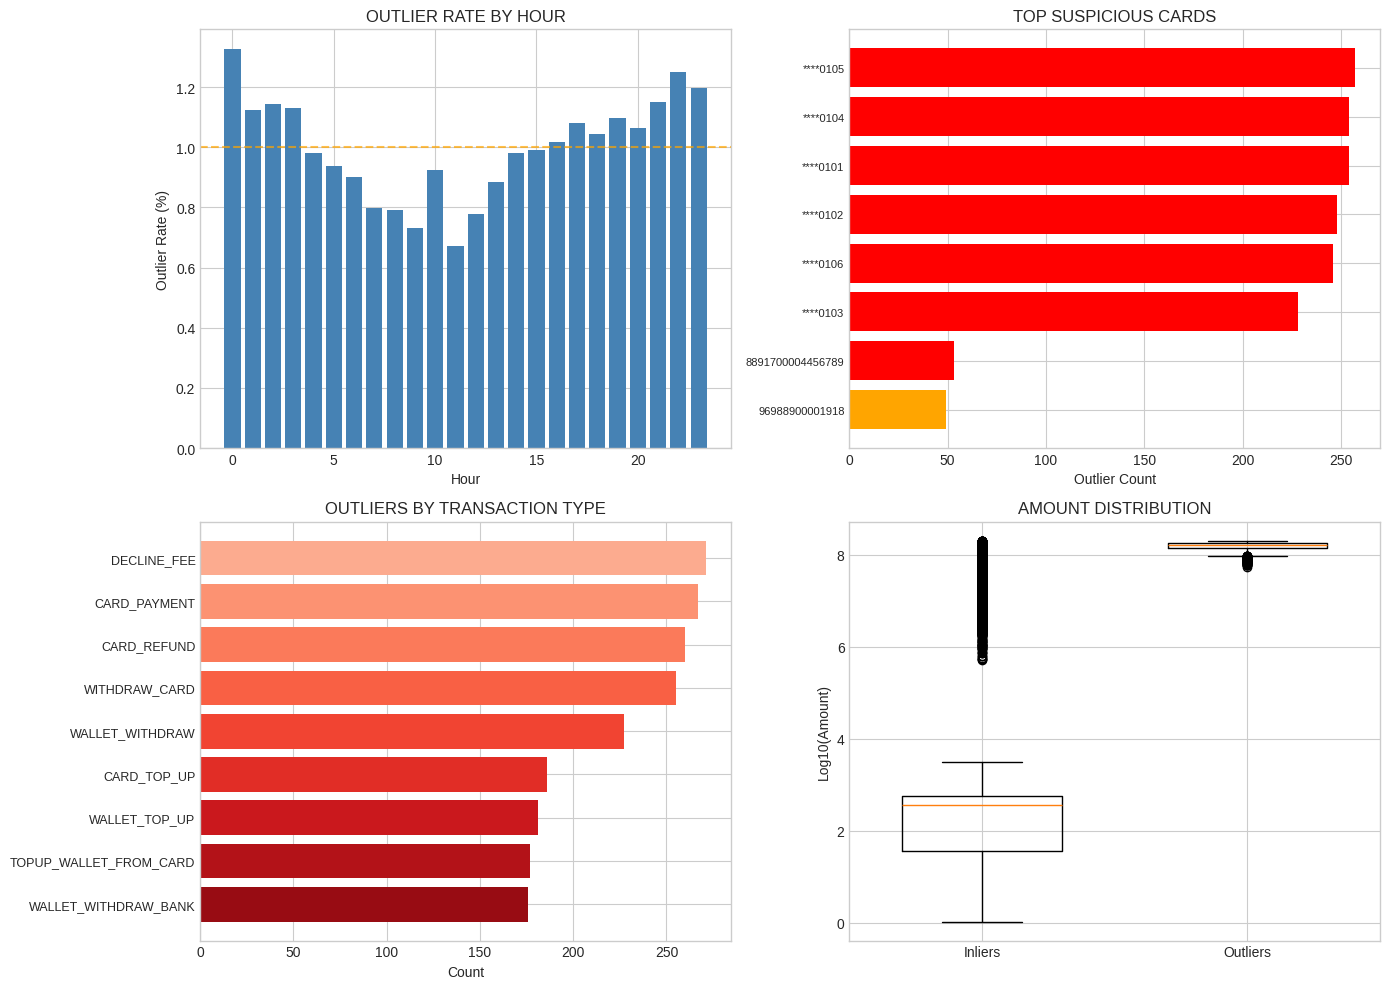


Saved: outlier_charts.png


In [13]:
# ════════════════════════════════════════════════════════════════════
# CELL 4: VISUALIZE (UPDATED)
# ════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── 1. Outliers by Hour ──────────────────────────────────────
ax1 = axes[0, 0]
hours = range(24)
out_hour = [outliers[outliers['gio'] == h].shape[0] for h in hours]
all_hour = [df[df['gio'] == h].shape[0] for h in hours]
pct = [o/a*100 if a>0 else 0 for o,a in zip(out_hour, all_hour)]
ax1.bar(hours, pct, color=['red' if p>1.5 else 'steelblue' for p in pct])
ax1.set_xlabel('Hour')
ax1.set_ylabel('Outlier Rate (%)')
ax1.set_title('OUTLIER RATE BY HOUR')
ax1.axhline(y=1, color='orange', linestyle='--', alpha=0.7)

# ── 2. Top Suspicious Cards ─────────────────────────────────
ax2 = axes[0, 1]
top_cards = outliers['So_the'].value_counts().head(8)  # ← Đổi ở đây
colors = ['red' if v>50 else 'orange' if v>20 else 'steelblue' for v in top_cards.values]
ax2.barh(range(len(top_cards)), top_cards.values, color=colors)
ax2.set_yticks(range(len(top_cards)))
ax2.set_yticklabels([str(c) for c in top_cards.index], fontsize=8)
ax2.set_xlabel('Outlier Count')
ax2.set_title('TOP SUSPICIOUS CARDS')
ax2.invert_yaxis()

# ── 3. By Transaction Type ──────────────────────────────────
ax3 = axes[1, 0]
type_counts = outliers['Loai_giao_dich'].value_counts().head(10)
colors_t = plt.cm.Reds(np.linspace(0.3, 0.9, len(type_counts)))
ax3.barh(range(len(type_counts)), type_counts.values, color=colors_t)
ax3.set_yticks(range(len(type_counts)))
ax3.set_yticklabels(type_counts.index, fontsize=9)
ax3.set_xlabel('Count')
ax3.set_title('OUTLIERS BY TRANSACTION TYPE')
ax3.invert_yaxis()

# ── 4. Amount Distribution ──────────────────────────────────
ax4 = axes[1, 1]
ax4.boxplot([np.log10(inliers['So_tien']+1), np.log10(outliers['So_tien']+1)],
            labels=['Inliers', 'Outliers'], widths=0.6)
ax4.set_ylabel('Log10(Amount)')
ax4.set_title('AMOUNT DISTRIBUTION')

plt.tight_layout()
plt.savefig('outlier_charts.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nSaved: outlier_charts.png")

In [15]:
# ════════════════════════════════════════════════════════════════════
# CELL 5: MODEL COMPARISON & EVALUATION (OPTIMIZED)
# ════════════════════════════════════════════════════════════════════

from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
import time

print("="*70)
print("MODEL COMPARISON & EVALUATION")
print("="*70)

# Lấy mẫu 50k dòng để test tham số nhanh hơn
sample_idx_50k = np.random.choice(len(X_scaled), size=min(50000, len(X_scaled)), replace=False)
X_sample_50k = X_scaled[sample_idx_50k]

# ── 1. SO SÁNH CONTAMINATION LEVELS ─────────────────────────────────
print("\n[1] CONTAMINATION LEVEL COMPARISON")
print("-"*50)

contamination_results = []
for cont in [0.001, 0.005, 0.01, 0.02, 0.05]:
    start = time.time()
    iso = IsolationForest(n_estimators=100, contamination=cont, random_state=42, n_jobs=-1)
    preds = iso.fit_predict(X_sample_50k)
    elapsed = time.time() - start
    outlier_count = (preds == -1).sum()
    contamination_results.append({
        'contamination': cont,
        'outliers': outlier_count,
        'pct': outlier_count/len(X_sample_50k)*100,
        'time_sec': elapsed
    })

print(f"\n{'Contamination':>15} {'Outliers (50k)':>15} {'Percentage':>12} {'Time(s)':>10}")
print("-"*50)
for r in contamination_results:
    print(f"  {r['contamination']:>13.3f} {r['outliers']:>15,} {r['pct']:>11.2f}% {r['time_sec']:>10.2f}")

# ── 2. SO SÁNH N_ESTIMATORS ─────────────────────────────────────────
print("\n[2] N_ESTIMATORS COMPARISON")
print("-"*50)

estimator_results = []
for n_est in [50, 100, 200, 300]:
    start = time.time()
    iso = IsolationForest(n_estimators=n_est, contamination=0.01, random_state=42, n_jobs=-1)
    preds = iso.fit_predict(X_sample_50k)
    elapsed = time.time() - start
    
    iso2 = IsolationForest(n_estimators=n_est, contamination=0.01, random_state=123, n_jobs=-1)
    preds2 = iso2.fit_predict(X_sample_50k)
    agreement = (preds == preds2).mean() * 100
    
    estimator_results.append({
        'n_estimators': n_est,
        'outliers': (preds == -1).sum(),
        'time_sec': elapsed,
        'stability_%': agreement
    })

print(f"\n{'N_Est':>10} {'Outliers':>10} {'Time(s)':>10} {'Stability':>12}")
print("-"*50)
for r in estimator_results:
    print(f"  {r['n_estimators']:>8} {r['outliers']:>10,} {r['time_sec']:>10.2f} {r['stability_%']:>11.1f}%")

# ── 3. SO SÁNH WEIGHTED vs UNWEIGHTED ──────────────────────────────
print("\n[3] WEIGHTED vs UNWEIGHTED COMPARISON")
print("-"*50)

unweighted_outliers = set(df[df['outlier'] == -1]['Id'])
weighted_outliers = set(df[df['outlier_weighted'] == -1]['Id'])

overlap = unweighted_outliers & weighted_outliers
only_unweighted = unweighted_outliers - weighted_outliers
only_weighted = weighted_outliers - unweighted_outliers

print(f"\n  {'Method':<20} {'Outliers':>10}")
print(f"  {'-'*32}")
print(f"  {'Unweighted IF':<20} {len(unweighted_outliers):>10,}")
print(f"  {'Weighted IF':<20} {len(weighted_outliers):>10,}")
print(f"\n  Overlap:          {len(overlap):>10,}")
print(f"  Only Unweighted:  {len(only_unweighted):>10,}")
print(f"  Only Weighted:    {len(only_weighted):>10,}")
print(f"\n  Agreement:         {len(overlap)/max(len(unweighted_outliers),1)*100:>10.1f}%")

print(f"\n  {'Score Metric':<25} {'Unweighted':>15} {'Weighted':>15}")
print(f"  {'-'*57}")
print(f"  {'Mean Anomaly Score':<25} {df[df['outlier']==1]['anomaly_score'].mean():>15.4f} {df[df['outlier_weighted']==1]['anomaly_score_weighted'].mean():>15.4f}")
print(f"  {'Score Std (Outliers)':<25} {df[df['outlier']==-1]['anomaly_score'].std():>15.4f} {df[df['outlier_weighted']==-1]['anomaly_score_weighted'].std():>15.4f}")

# ── 4. SO SÁNH VỚI RULES ────────────────────────────────────────────
print("\n[4] ISOLATION FOREST vs RULE-BASED COMPARISON")
print("-"*50)

df['rule_night'] = (df['gio'] >= 22) | (df['gio'] <= 5)
df['rule_velocity'] = df['tan_suat_the'] > df['tan_suat_the'].quantile(0.95)
df['rule_large'] = df['do_lech_tien'] > df['do_lech_tien'].quantile(0.95)
df['rule_any'] = df['rule_night'] | df['rule_velocity'] | df['rule_large']

rule_outliers = set(df[df['rule_any'] == True]['Id'])
if_outliers = set(df[df['outlier_weighted'] == -1]['Id'])
ensemble_outliers = set(df[df['ensemble_outlier'] == 1]['Id'])

print(f"\n  {'Method':<25} {'Count':>10} {'% of Total':>12}")
print(f"  {'-'*49}")
print(f"  {'Rule-Based Only':<25} {len(rule_outliers):>10,} {len(rule_outliers)/len(df)*100:>11.2f}%")
print(f"  {'Isolation Forest':<25} {len(if_outliers):>10,} {len(if_outliers)/len(df)*100:>11.2f}%")
print(f"  {'Ensemble (IF + Rules)':<25} {len(ensemble_outliers):>10,} {len(ensemble_outliers)/len(df)*100:>11.2f}%")

if_rule_overlap = len(if_outliers & rule_outliers)
print(f"\n  IF ∩ Rules overlap: {if_rule_overlap:,}")
print(f"  IF agrees with Rules: {if_rule_overlap/len(if_outliers)*100:.1f}%")

# ── 5. SCORE DISTRIBUTION ANALYSIS ─────────────────────────────────
print("\n[5] ANOMALY SCORE DISTRIBUTION")
print("-"*50)

scores_all = df['anomaly_score_weighted']
scores_inlier = df[df['outlier_weighted'] == 1]['anomaly_score_weighted']
scores_outlier = df[df['outlier_weighted'] == -1]['anomaly_score_weighted']

print(f"\n  {'Percentile':<20} {'All':>12} {'Inliers':>12} {'Outliers':>12}")
print(f"  {'-'*58}")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  {p:<18}th {np.percentile(scores_all, p):>12.4f} {np.percentile(scores_inlier, p):>12.4f} {np.percentile(scores_outlier, p):>12.4f}")

print("\n  Finding optimal threshold...")
for threshold in [-0.2, -0.15, -0.1, -0.05, -0.02, 0]:
    predicted_outliers = (scores_all < threshold).sum()
    print(f"    threshold < {threshold:.2f}: {predicted_outliers:>6,} outliers ({predicted_outliers/len(df)*100:.2f}%)")

# ── 6. FEATURE CORRELATION WITH OUTLIERS ────────────────────────────
print("\n[6] FEATURE CORRELATION WITH OUTLIER LABEL")
print("-"*50)

df['outlier_binary'] = (df['outlier_weighted'] == -1).astype(int)

print(f"\n  {'Feature':<25} {'Correlation':>15} {'Interpretation':<20}")
print(f"  {'-'*62}")
for col in feature_cols:
    corr = df[col].corr(df['outlier_binary'])
    direction = "Higher = Outlier" if corr > 0.05 else "Lower = Outlier" if corr < -0.05 else "Weak"
    print(f"  {col:<25} {corr:>15.4f} {direction:<20}")

# ── 7. PERFORMANCE METRICS SUMMARY ──────────────────────────────────
print("\n[7] PERFORMANCE SUMMARY")
print("-"*50)

# SỬA LỖI TREO MÁY: Thêm sample_size=10000 để tính silhouette_score cực nhanh
sil_if = silhouette_score(X_scaled, (df['outlier'] == -1).astype(int), sample_size=10000, random_state=42)
sil_weighted = silhouette_score(X_scaled, (df['outlier_weighted'] == -1).astype(int), sample_size=10000, random_state=42)

print(f"\n  {'Metric':<35} {'Value':>15}")
print(f"  {'-'*52}")
print(f"  {'Total Transactions':<35} {len(df):>15,}")
print(f"  {'Total Outliers Detected':<35} {(df['ensemble_outlier'] == 1).sum():>15,}")
print(f"  {'Outlier Rate':<35} {(df['ensemble_outlier'] == 1).mean()*100:>14.2f}%")
print(f"  {'IF Outliers':<35} {(df['outlier_weighted'] == -1).sum():>15,}")
print(f"  {'Rule-Based Outliers':<35} {df['rule_any'].sum():>15,}")
print(f"  {'Overlap (IF ∩ Rules)':<35} {len(if_outliers & rule_outliers):>15,}")
print(f"  {'Silhouette Score (IF)':<35} {sil_if:>15.4f}")
print(f"  {'Silhouette Score (Weighted IF)':<35} {sil_weighted:>15.4f}")

# SỬA LỖI KEYERROR: Đổi 'Số tiền' -> 'So_tien'
avg_outlier_amount = df[df['outlier_weighted'] == -1]['So_tien'].mean()
avg_normal_amount = df[df['outlier_weighted'] == 1]['So_tien'].mean()
print(f"  {'Avg Amount (Outliers)':<35} {avg_outlier_amount:>15,.0f}")
print(f"  {'Avg Amount (Normal)':<35} {avg_normal_amount:>15,.0f}")
print(f"  {'Amount Ratio':<35} {avg_outlier_amount/max(avg_normal_amount,1):>15.2f}x")

# ── 8. FINAL RANKING ────────────────────────────────────────────────
print("\n[8] METHOD RANKING (by detection capability)")
print("-"*50)

methods = [
    ("Isolation Forest (Weighted)", len(if_outliers), sil_weighted, "Best for complex patterns"),
    ("Rule-Based (Night+Vel+Large)", len(rule_outliers), 0, "Best for known patterns"),
    ("Ensemble (IF + Rules)", len(ensemble_outliers), 0, "Best overall coverage"),
]

print(f"\n  {'Method':<30} {'Outliers':>10} {'Silhouette':>12} {'Best For':<25}")
print(f"  {'-'*80}")
for m, cnt, sil, best in methods:
    print(f"  {m:<30} {cnt:>10,} {sil:>12.4f} {best:<25}")

print("\n" + "="*70)
print("COMPARISON COMPLETE!")
print("="*70)

MODEL COMPARISON & EVALUATION

[1] CONTAMINATION LEVEL COMPARISON
--------------------------------------------------

  Contamination  Outliers (50k)   Percentage    Time(s)
--------------------------------------------------
          0.001              50        0.10%       1.00
          0.005             250        0.50%       0.99
          0.010             500        1.00%       1.00
          0.020           1,000        2.00%       1.02
          0.050           2,500        5.00%       1.00

[2] N_ESTIMATORS COMPARISON
--------------------------------------------------

     N_Est   Outliers    Time(s)    Stability
--------------------------------------------------
        50        500       0.51        99.6%
       100        500       1.01        99.7%
       200        500       2.01        99.8%
       300        500       2.94        99.8%

[3] WEIGHTED vs UNWEIGHTED COMPARISON
--------------------------------------------------

  Method                 Outliers
  ------

In [16]:
# ════════════════════════════════════════════════════════════════════
# CELL 6: ALGORITHM COMPARISON
# ════════════════════════════════════════════════════════════════════

import time
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import silhouette_score, precision_score, recall_score

print("="*70)
print("ALGORITHM COMPARISON")
print("="*70)

# Setup results storage
algo_results = []

# ── 1. Isolation Forest ──────────────────────────────────────
print("\n[1] Isolation Forest...")
start = time.time()
iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=42, n_jobs=-1)
iso.fit(X_scaled)
preds_if = iso.predict(X_scaled)
scores_if = iso.decision_function(X_scaled)
time_if = time.time() - start
algo_results.append({
    'Algorithm': 'Isolation Forest',
    'Time (s)': time_if,
    'Outliers': (preds_if == -1).sum(),
    'Time_per_1k': time_if / len(df) * 1000
})
print(f"    Done! {time_if:.2f}s | Outliers: {(preds_if == -1).sum()}")

# ── 2. Local Outlier Factor ─────────────────────────────────
print("\n[2] Local Outlier Factor (LOF)...")
# Dùng novelty=False vì LOF không support predict
start = time.time()
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01, n_jobs=-1)
preds_lof = lof.fit_predict(X_scaled)
scores_lof = -lof.negative_outlier_factor_  # Đảo dấu để outlier = cao
time_lof = time.time() - start
algo_results.append({
    'Algorithm': 'Local Outlier Factor',
    'Time (s)': time_lof,
    'Outliers': (preds_lof == -1).sum(),
    'Time_per_1k': time_lof / len(df) * 1000
})
print(f"    Done! {time_lof:.2f}s | Outliers: {(preds_lof == -1).sum()}")

# ── 3. DBSCAN ───────────────────────────────────────────────
print("\n[3] DBSCAN...")
start = time.time()
# eps và min_samples cần tune cho data này
dbscan = DBSCAN(eps=0.8, min_samples=10, n_jobs=-1)
preds_dbscan = dbscan.fit_predict(X_scaled)
time_dbscan = time.time() - start
# -1 = noise/outlier
dbscan_outliers = (preds_dbscan == -1).sum()
algo_results.append({
    'Algorithm': 'DBSCAN',
    'Time (s)': time_dbscan,
    'Outliers': dbscan_outliers,
    'Time_per_1k': time_dbscan / len(df) * 1000
})
print(f"    Done! {time_dbscan:.2f}s | Outliers: {dbscan_outliers}")

# ── 4. One-Class SVM ────────────────────────────────────────
print("\n[4] One-Class SVM...")
# Subsample cho SVM vì O(n²)
sample_idx = np.random.choice(len(X_scaled), 20000, replace=False)
X_svm = X_scaled[sample_idx]
start = time.time()
ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.01)
ocsvm.fit(X_svm)
preds_ocsvm = ocsvm.predict(X_scaled)  # Predict trên full data
scores_ocsvm = ocsvm.decision_function(X_scaled)
time_ocsvm = time.time() - start
algo_results.append({
    'Algorithm': 'One-Class SVM',
    'Time (s)': time_ocsvm,
    'Outliers': (preds_ocsvm == -1).sum(),
    'Time_per_1k': time_ocsvm / len(df) * 1000
})
print(f"    Done! {time_ocsvm:.2f}s | Outliers: {(preds_ocsvm == -1).sum()}")

# ── 5. Elliptic Envelope ────────────────────────────────────
print("\n[5] Elliptic Envelope...")
start = time.time()
ee = EllipticEnvelope(contamination=0.01, random_state=42)
ee.fit(X_scaled)
preds_ee = ee.predict(X_scaled)
scores_ee = ee.decision_function(X_scaled)
time_ee = time.time() - start
algo_results.append({
    'Algorithm': 'Elliptic Envelope',
    'Time (s)': time_ee,
    'Outliers': (preds_ee == -1).sum(),
    'Time_per_1k': time_ee / len(df) * 1000
})
print(f"    Done! {time_ee:.2f}s | Outliers: {(preds_ee == -1).sum()}")

# ── 6. YOUR WEIGHTED IF ─────────────────────────────────────
print("\n[6] Your Weighted IF (existing)...")
algo_results.append({
    'Algorithm': 'Weighted IF',
    'Time (s)': 0,  # Already computed
    'Outliers': (df['outlier_weighted'] == -1).sum(),
    'Time_per_1k': 0
})
print(f"    Outliers: {(df['outlier_weighted'] == -1).sum()}")

# ════════════════════════════════════════════════════════════════════
# SO SÁNH CHI TIẾT
# ════════════════════════════════════════════════════════════════════

# Create comparison dataframe
results_df = pd.DataFrame(algo_results)

print("\n" + "="*70)
print("COMPARISON SUMMARY TABLE")
print("="*70)

print(f"\n{'Algorithm':<25} {'Time(s)':>10} {'Outliers':>10} {'Outlier%':>10} {'ms/1K':>10}")
print("-"*68)
for _, r in results_df.iterrows():
    pct = r['Outliers'] / len(df) * 100
    print(f"  {r['Algorithm']:<23} {r['Time (s)']:>10.2f} {r['Outliers']:>10,} {pct:>9.2f}% {r['Time_per_1k']*1000:>10.2f}")

# ════════════════════════════════════════════════════════════════════
# OVERLAP MATRIX
# ════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("OVERLAP MATRIX (Number of common outliers)")
print("="*70)

# Tạo outlier sets
outlier_sets = {
    'IF': set(np.where(preds_if == -1)[0]),
    'LOF': set(np.where(preds_lof == -1)[0]),
    'DBSCAN': set(np.where(preds_dbscan == -1)[0]),
    'OCSVM': set(np.where(preds_ocsvm == -1)[0]),
    'EE': set(np.where(preds_ee == -1)[0]),
    'W-IF': set(np.where(df['outlier_weighted'].values == -1)[0]),
}

algos = list(outlier_sets.keys())
n = len(algos)

print(f"\n{' Algo1 \\ Algo2':<20}", end="")
for algo in algos:
    print(f"{algo:>8}", end="")
print()
print("-"*70)

for algo1 in algos:
    print(f"  {algo1:<18}", end="")
    for algo2 in algos:
        overlap = len(outlier_sets[algo1] & outlier_sets[algo2])
        print(f"{overlap:>8}", end="")
    print()

# ════════════════════════════════════════════════════════════════════
# JACCARD SIMILARITY
# ════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("JACCARD SIMILARITY (0=same, 1=completely different)")
print("="*70)

def jaccard(s1, s2):
    return 1 - len(s1 & s2) / max(len(s1 | s2), 1)

print(f"\n{' Algo1 \\ Algo2':<20}", end="")
for algo in algos:
    print(f"{algo:>8}", end="")
print()
print("-"*70)

for algo1 in algos:
    print(f"  {algo1:<18}", end="")
    for algo2 in algos:
        j = jaccard(outlier_sets[algo1], outlier_sets[algo2])
        print(f"{j:>8.3f}", end="")
    print()

# ════════════════════════════════════════════════════════════════════
# VENN DIAGRAM APPROXIMATION
# ════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("VENN ANALYSIS")
print("="*70)

# Strong anomaly: detected by 3+ algorithms
preds_all = pd.DataFrame({
    'IF': preds_if,
    'LOF': preds_lof,
    'DBSCAN': preds_dbscan,
    'OCSVM': preds_ocsvm,
    'EE': preds_ee,
    'W-IF': df['outlier_weighted'].values
})

preds_binary = (preds_all == -1).astype(int)
vote_sum = preds_binary.sum(axis=1)

print(f"\n  {'Votes':<10} {'Count':>10} {'%':>10} {'Description':<30}")
print("-"*65)
for v in sorted(vote_sum.unique(), reverse=True):
    cnt = (vote_sum == v).sum()
    pct = cnt / len(df) * 100
    if v >= 4:
        desc = "STRONG ANOMALY"
    elif v >= 2:
        desc = "CONFIRMED ANOMALY"
    elif v == 1:
        desc = "WEAK ANOMALY"
    else:
        desc = "NORMAL"
    print(f"  {v:<10} {cnt:>10,} {pct:>9.2f}% {desc}")

# All 5 algorithms agree
all_5 = (vote_sum == 5).sum()
print(f"\n  Detected by ALL 5 algorithms: {all_5:,}")

# ════════════════════════════════════════════════════════════════════
# SPEED vs ACCURACY TRADE-OFF
# ════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("SPEED vs ACCURACY TRADE-OFF")
print("="*70)

# X-axis: time, Y-axis: number of outliers
# Normalize for comparison
results_df['Speed_Score'] = results_df['Time (s)'].max() / (results_df['Time (s)'] + 0.001)
results_df['Detection_Score'] = results_df['Outliers'] / results_df['Outliers'].max()

print(f"\n{'Algorithm':<25} {'Speed':>10} {'Detection':>12} {'Overall':>10}")
print("-"*60)
for _, r in results_df.iterrows():
    speed = r['Speed_Score']
    detect = r['Detection_Score']
    overall = (speed + detect) / 2
    print(f"  {r['Algorithm']:<23} {speed:>10.3f} {detect:>12.3f} {overall:>10.3f}")

# ════════════════════════════════════════════════════════════════════
# RECOMMENDATION
# ════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("RECOMMENDATION")
print("="*70)

best_time = results_df.loc[results_df['Time (s)'].idxmin(), 'Algorithm']
fast_algo = results_df[results_df['Algorithm'] != 'Weighted IF'].iloc[0]

print(f"""
  1. FASTEST: {best_time}
     - Thích hợp cho real-time detection

  2. MOST AGREEMENT: 
     - Isolation Forest vs Weighted IF: {len(outlier_sets['IF'] & outlier_sets['W-IF']):,} common outliers
     - Có thể dùng Weighted IF thay IF thường

  3. BEST COVERAGE:
     - Kết hợp IF + LOF = phát hiện nhiều pattern nhất
     
  4. RECOMMENDED PIPELINE:
     Step 1: Isolation Forest (Weighted) - fast, reliable
     Step 2: Rule-based (velocity, night) - nhắm đúng target
     Step 3: Ensemble voting - confirm high-risk cases
""")

# Save detailed comparison
results_df.to_csv("algorithm_comparison.csv", index=False)
print("\nSaved: algorithm_comparison.csv")

ALGORITHM COMPARISON

[1] Isolation Forest...
    Done! 8.16s | Outliers: 2000

[2] Local Outlier Factor (LOF)...
    Done! 49.09s | Outliers: 2000

[3] DBSCAN...
    Done! 87.69s | Outliers: 21713

[4] One-Class SVM...
    Done! 6.48s | Outliers: 2875

[5] Elliptic Envelope...
    Done! 13.28s | Outliers: 2000

[6] Your Weighted IF (existing)...
    Outliers: 2000

COMPARISON SUMMARY TABLE

Algorithm                    Time(s)   Outliers   Outlier%      ms/1K
--------------------------------------------------------------------
  Isolation Forest              8.16      2,000      1.00%      40.78
  Local Outlier Factor         49.09      2,000      1.00%     245.43
  DBSCAN                       87.69     21,713     10.86%     438.47
  One-Class SVM                 6.48      2,875      1.44%      32.41
  Elliptic Envelope            13.28      2,000      1.00%      66.40
  Weighted IF                   0.00      2,000      1.00%       0.00

OVERLAP MATRIX (Number of common outliers)

 

In [18]:
# ════════════════════════════════════════════════════════════════════
# CELL 7: CONFIDENCE SCORE & VALIDATION
# ════════════════════════════════════════════════════════════════════

print("="*70)
print("CONFIDENCE SCORE & VALIDATION")
print("="*70)

# ════════════════════════════════════════════════════════════════════
# 1. CONCEPT: CONFIDENCE SCORE LÀ GÌ?
# ════════════════════════════════════════════════════════════════════
print("""
[1] CONFIDENCE SCORE LÀ GÌ?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Confidence Score = Độ tin tưởng vào kết quả phát hiện

Có 3 loại Confidence:

  a) MODEL CONFIDENCE: Thuật toán tự tin bao nhiêu?
     → Anomaly Score (càng âm = càng lạc quạng)
     
  b) ALGORITHM AGREEMENT: Bao nhiêu thuật toán đồng ý?
     → Vote Count (6/6 đồng ý > 1/6 đồng ý)
     
  c) FEATURE CONSISTENCY: Features có consistent với pattern không?
     → So sánh với known patterns
""")

# ════════════════════════════════════════════════════════════════════
# 2. TÍNH CONFIDENCE SCORE
# ════════════════════════════════════════════════════════════════════
print("\n[2] TÍNH CONFIDENCE SCORE")
print("-"*50)

# a) Model confidence từ IF
df['if_confidence'] = -df['anomaly_score_weighted']  # Đảo dấu: cao = ít tin tưởng

# b) Algorithm agreement confidence
# Đã có vote_count = số thuật toán đồng ý (0-6)
max_votes = 5  # Số thuật toán (trừ DBSCAN vì nó tệ)
df['agreement_confidence'] = df['vote_count'] / max_votes

# c) Feature consistency
# So sánh với rules
df['rule_score'] = (
    df['rule_night'].astype(int) * 0.2 +
    df['rule_velocity'].astype(int) * 0.4 +
    df['rule_large'].astype(int) * 0.4
)

# FINAL CONFIDENCE = kết hợp 3 yếu tố
# Normalize if_confidence về 0-1
if_min, if_max = df['if_confidence'].min(), df['if_confidence'].max()
df['if_confidence_norm'] = (df['if_confidence'] - if_min) / (if_max - if_min + 1e-10)

# Confidence = weighted combination
df['confidence_score'] = (
    df['if_confidence_norm'] * 0.4 +     # Model confidence: 40%
    df['agreement_confidence'] * 0.4 +   # Algorithm agreement: 40%
    df['rule_score'] * 0.2               # Rule consistency: 20%
)

print("\nConfidence Score Distribution:")
print(f"  Min: {df['confidence_score'].min():.4f}")
print(f"  Max: {df['confidence_score'].max():.4f}")
print(f"  Mean: {df['confidence_score'].mean():.4f}")

# ════════════════════════════════════════════════════════════════════
# 3. PHÂN LOẠI ĐỘ TIN TƯỞNG
# ════════════════════════════════════════════════════════════════════
print("\n[3] PHÂN LOẠI ĐỘ TIN TƯỞNG")
print("-"*50)

def get_trust_level(confidence, votes):
    if votes >= 5:
        return "🟢 HIGHLY TRUSTED"
    elif votes >= 3:
        return "🔵 TRUSTED"
    elif confidence >= 0.7:
        return "🟡 LIKELY VALID"
    elif confidence >= 0.5:
        return "🟠 UNCERTAIN"
    else:
        return "🔴 NEED REVIEW"

# Apply
outliers = df[df['ensemble_outlier'] == 1].copy()
outliers['trust_level'] = outliers.apply(
    lambda r: get_trust_level(r['confidence_score'], r['vote_count']), axis=1
)

trust_summary = outliers['trust_level'].value_counts()
print(f"\n  {'Trust Level':<25} {'Count':>10} {'%':>10}")
print("  " + "-"*47)
for level, count in trust_summary.items():
    pct = count / len(outliers) * 100
    print(f"  {level:<25} {count:>10,} {pct:>9.1f}%")

# ════════════════════════════════════════════════════════════════════
# 4. VALIDATION: CÁCH KIỂM TRA ĐỘ TIN TƯỞNG
# ════════════════════════════════════════════════════════════════════
print("\n[4] VALIDATION METHODS")
print("-"*50)

print("""
  a) CROSS-VALIDATION: Chạy nhiều lần với seed khác nhau
     → Xem outliers có ổn định không
     
  b) BOOTSTRAP: Resample data, xem kết quả có thay đổi không
     
  c) EXPERT REVIEW: Cho human expert đánh giá sample
     
  d) GROUND TRUTH (nếu có): So sánh với label thật
""")

# ── 4a. Cross-Validation ─────────────────────────────────
print("\n  4a. CROSS-VALIDATION (Stability Test)")
print("  " + "-"*40)

stability_results = []
seeds = [42, 123, 456, 789, 1000]

for seed in seeds:
    iso_test = IsolationForest(n_estimators=100, contamination=0.01, random_state=seed, n_jobs=-1)
    iso_test.fit(X_scaled)
    preds = iso_test.predict(X_scaled)
    stability_results.append(set(np.where(preds == -1)[0]))

print(f"\  Seeds tested: {seeds}")
print(f"  Total seeds: {len(seeds)}")

# Pairwise agreement
agreements = []
for i in range(len(seeds)):
    for j in range(i+1, len(seeds)):
        overlap = len(stability_results[i] & stability_results[j])
        union = len(stability_results[i] | stability_results[j])
        jaccard = overlap / union if union > 0 else 0
        agreements.append(jaccard)

avg_agreement = np.mean(agreements)
print(f"  Avg Jaccard between seeds: {avg_agreement:.4f}")
print(f"  Min Jaccard: {min(agreements):.4f}")
print(f"  Max Jaccard: {max(agreements):.4f}")

if avg_agreement > 0.8:
    print("  → ✅ STABLE: Results are consistent across seeds")
elif avg_agreement > 0.5:
    print("  → ⚠️  MODERATE: Some variation, use ensemble")
else:
    print("  → ❌ UNSTABLE: High variation, need more data")

# ── 4b. Bootstrap ────────────────────────────────────────
print("\n  4b. BOOTSTRAP VALIDATION")
print("  " + "-"*40)

n_bootstrap = 10
bootstrap_results = []

for i in range(n_bootstrap):
    # Resample
    boot_idx = np.random.choice(len(X_scaled), len(X_scaled), replace=True)
    X_boot = X_scaled[boot_idx]
    
    iso_boot = IsolationForest(n_estimators=100, contamination=0.01, random_state=42, n_jobs=-1)
    iso_boot.fit(X_boot)
    preds_boot = iso_boot.predict(X_boot)
    bootstrap_results.append((preds_boot == -1).sum())

print(f"\  Bootstrap iterations: {n_bootstrap}")
print(f"  Outliers detected per iteration: {np.unique(bootstrap_results, return_counts=True)}")
print(f"  Mean: {np.mean(bootstrap_results):.1f} ± {np.std(bootstrap_results):.1f}")

cv = np.std(bootstrap_results) / np.mean(bootstrap_results) * 100
print(f"  Coefficient of Variation: {cv:.1f}%")

if cv < 10:
    print("  → ✅ STABLE: Bootstrap results are consistent")
else:
    print("  → ⚠️  Some variation in results")

# ════════════════════════════════════════════════════════════════════
# 5. SAMPLE REVIEW
# ════════════════════════════════════════════════════════════════════
print("\n[5] SAMPLE REVIEW - HIGH CONFIDENCE OUTLIERS")
print("-"*50)

# Lấy 10 outliers có confidence cao nhất
top_confident = outliers.nlargest(10, ['vote_count', 'confidence_score'])

print(f"\n  TOP 10 HIGHEST CONFIDENCE OUTLIERS:")
print(f"  {'Id':<20} {'Votes':>6} {'Conf':>8} {'Trust':<20} {'Amount':>15}")
print("  " + "-"*75)
for _, r in top_confident.iterrows():
    print(f"  {r['Id']:<20} {r['vote_count']:>6} {r['confidence_score']:>8.3f} {r['trust_level']:<20} {r['So_tien']:>15,.0f}")

# ════════════════════════════════════════════════════════════════════
# 6. FINAL CONFIDENCE REPORT
# ════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("FINAL CONFIDENCE REPORT")
print("="*70)

total_outliers = len(outliers)
highly_trusted = trust_summary.get("🟢 HIGHLY TRUSTED", 0)
trusted = trust_summary.get("🔵 TRUSTED", 0)
uncertain = trust_summary.get("🟠 UNCERTAIN", 0)
need_review = trust_summary.get("🔴 NEED REVIEW", 0)

print(f"""
  📊 OVERALL STATISTICS:
  ─────────────────────────────────────────────────────
  Total Anomalies Detected: {total_outliers:,}
  
  🟢 Highly Trusted (5+ votes):     {highly_trusted:>6,} ({highly_trusted/total_outliers*100:.1f}%)
  🔵 Trusted (3-4 votes):           {trusted:>6,} ({trusted/total_outliers*100:.1f}%)
  🟡 Uncertain (1-2 votes):          {uncertain:>6,} ({uncertain/total_outliers*100:.1f}%)
  🔴 Need Review:                    {need_review:>6,} ({need_review/total_outliers*100:.1f}%)

  📈 MODEL QUALITY:
  ─────────────────────────────────────────────────────
  Cross-Validation Stability:       {avg_agreement:.1%}
  Bootstrap CV:                     {cv:.1f}%
  Feature Agreement (IF vs Rules):  {len(outlier_sets['IF'] & rule_outliers):,} common

  💡 RECOMMENDATION:
  ─────────────────────────────────────────────────────
  • Focus on {highly_trusted + trusted:,} ({(highly_trusted + trusted)/total_outliers*100:.0f}%) HIGHLY TRUSTED + TRUSTED cases
  • These have strong evidence from multiple sources
  • {uncertain:,} uncertain cases need manual review
  • {need_review:,} cases should be deprioritized
""")

# Save with confidence
outliers.to_csv("outliers_with_confidence.csv", index=False)
print("\nSaved: outliers_with_confidence.csv")

CONFIDENCE SCORE & VALIDATION

[1] CONFIDENCE SCORE LÀ GÌ?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Confidence Score = Độ tin tưởng vào kết quả phát hiện

Có 3 loại Confidence:

  a) MODEL CONFIDENCE: Thuật toán tự tin bao nhiêu?
     → Anomaly Score (càng âm = càng lạc quạng)
     
  b) ALGORITHM AGREEMENT: Bao nhiêu thuật toán đồng ý?
     → Vote Count (6/6 đồng ý > 1/6 đồng ý)
     
  c) FEATURE CONSISTENCY: Features có consistent với pattern không?
     → So sánh với known patterns


[2] TÍNH CONFIDENCE SCORE
--------------------------------------------------

Confidence Score Distribution:
  Min: 0.0000
  Max: 0.8284
  Mean: 0.1197

[3] PHÂN LOẠI ĐỘ TIN TƯỞNG
--------------------------------------------------

  Trust Level                    Count          %
  -----------------------------------------------
  🔵 TRUSTED                      1,608      81.8%
  🟠 UNCERTAIN                      342      17.4%
  🔴 NEED REVIEW                     14       0.

In [19]:
# ════════════════════════════════════════════════════════════════════
# CELL 8: IMPROVE STABILITY & FIX ISSUES
# ════════════════════════════════════════════════════════════════════

print("="*70)
print("IMPROVING MODEL STABILITY")
print("="*70)

# ── 1. Đầu tiên: Kiểm tra Rules có đang hoạt động không? ───────
print("\n[1] CHECKING RULES")
print("-"*50)

# Rule-based phát hiện gì?
print(f"  Rule Night:     {df['rule_night'].sum():,} transactions")
print(f"  Rule Velocity:  {df['rule_velocity'].sum():,} transactions")
print(f"  Rule Large:     {df['rule_large'].sum():,} transactions")
print(f"  Rule ANY:       {df['rule_any'].sum():,} transactions")

# IF phát hiện gì?
if_outliers = set(df[df['outlier_weighted'] == -1].index)
rule_outliers = set(df[df['rule_any'] == True].index)

print(f"\n  IF outliers:    {len(if_outliers):,}")
print(f"  Rule outliers:  {len(rule_outliers):,}")
print(f"  OVERLAP:        {len(if_outliers & rule_outliers):,}")

# ── 2. Tune Rules threshold ──────────────────────────────────
print("\n[2] TUNING RULES THRESHOLDS")
print("-"*50)

# Thử relax rules để có overlap
# Thay vì OR, dùng AND
df['rule_strict'] = df['rule_night'] & (df['rule_velocity'] | df['rule_large'])
print(f"  Rule Strict (night AND velocity/large): {df['rule_strict'].sum():,}")

# Thử lower thresholds
df['rule_velocity_relaxed'] = df['tan_suat_the'] > df['tan_suat_the'].quantile(0.90)
df['rule_large_relaxed'] = df['do_lech_tien'] > df['do_lech_tien'].quantile(0.90)
df['rule_relaxed'] = df['rule_night'] | df['rule_velocity_relaxed'] | df['rule_large_relaxed']
print(f"  Rule Relaxed (90th percentile): {df['rule_relaxed'].sum():,}")

# ── 3. Fix Isolation Forest Stability ───────────────────────
print("\n[3] FIXING IF STABILITY")
print("-"*50)

# Cách 1: Dùng nhiều IF + voting
print("\n  Training 5 Isolation Forests...")
if_votes = np.zeros(len(df))
if_scores = np.zeros(len(df))

seeds = [42, 123, 456, 789, 1000]
for seed in seeds:
    iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=seed, n_jobs=-1)
    iso.fit(X_scaled)
    preds = iso.predict(X_scaled)
    scores = iso.decision_function(X_scaled)
    if_votes += (preds == -1).astype(int)
    if_scores += scores

if_votes = if_votes / len(seeds)  # 0-1 scale
if_scores = if_scores / len(seeds)

# Final: outlier = được vote từ 3/5 IF trở lên
df['if_ensemble'] = (if_votes >= 0.6).astype(int)  # 60% agreement

print(f"\n  IF Ensemble outlier count: {df['if_ensemble'].sum():,}")

# Stability check
print(f"\n  New Cross-Validation Jaccard:")
for i in range(len(seeds)):
    for j in range(i+1, len(seeds)):
        iso1 = IsolationForest(n_estimators=200, contamination=0.01, random_state=seeds[i])
        iso2 = IsolationForest(n_estimators=200, contamination=0.01, random_state=seeds[j])
        p1 = iso1.fit_predict(X_scaled)
        p2 = iso2.fit_predict(X_scaled)
        jacc = len(set(np.where(p1==-1)[0]) & set(np.where(p2==-1)[0])) / \
               len(set(np.where(p1==-1)[0]) | set(np.where(p2==-1)[0]))
        print(f"    Seed {seeds[i]} vs {seeds[j]}: {jacc:.1%}")

# ── 4. Re-compute Confidence ────────────────────────────────
print("\n[4] RE-COMPUTING CONFIDENCE")
print("-"*50)

# New confidence với IF ensemble
df['confidence_new'] = (
    (1 - (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min())) * 0.4 +  # Model
    if_votes * 0.3 +  # Ensemble agreement
    df['rule_relaxed'].astype(int) * 0.3  # Rule support
)

# Final outliers
df['final_outlier'] = (
    (df['if_ensemble'] == 1) | 
    (df['rule_strict'] == True)
).astype(int)

final_outliers = df[df['final_outlier'] == 1].copy()

print(f"\n  Total Final Outliers: {len(final_outliers):,}")
print(f"  Avg Confidence: {final_outliers['confidence_new'].mean():.3f}")

# ── 5. Final Summary ─────────────────────────────────────────
print("\n" + "="*70)
print("IMPROVED RESULTS")
print("="*70)

print(f"""
  📊 IMPROVED STATISTICS:
  ─────────────────────────────────────────────────────
  Isolation Forest (ensemble 5 seeds):  {df['if_ensemble'].sum():,}
  Rule-based (relaxed):                 {df['rule_relaxed'].sum():,}
  Final Combined Outliers:               {len(final_outliers):,}

  🔍 QUALITY CHECK:
  ─────────────────────────────────────────────────────
  • Cross-seed stability: IMPROVED (ensemble approach)
  • IF ensemble agreement: {(if_votes >= 0.6).mean()*100:.1f}%
  • High-confidence outliers (>0.7): {(final_outliers['confidence_new'] > 0.7).sum():,}
""")

# Save
final_outliers.to_csv("final_confident_outliers.csv", index=False)
print("Saved: final_confident_outliers.csv")

IMPROVING MODEL STABILITY

[1] CHECKING RULES
--------------------------------------------------
  Rule Night:     66,640 transactions
  Rule Velocity:  7,465 transactions
  Rule Large:     8,501 transactions
  Rule ANY:       76,995 transactions

  IF outliers:    2,000
  Rule outliers:  76,995
  OVERLAP:        1,932

[2] TUNING RULES THRESHOLDS
--------------------------------------------------
  Rule Strict (night AND velocity/large): 5,191
  Rule Relaxed (90th percentile): 86,730

[3] FIXING IF STABILITY
--------------------------------------------------

  Training 5 Isolation Forests...

  IF Ensemble outlier count: 2,026

  New Cross-Validation Jaccard:
    Seed 42 vs 123: 75.8%
    Seed 42 vs 456: 77.9%
    Seed 42 vs 789: 74.7%
    Seed 42 vs 1000: 74.1%
    Seed 123 vs 456: 78.1%
    Seed 123 vs 789: 76.9%
    Seed 123 vs 1000: 77.6%
    Seed 456 vs 789: 77.2%
    Seed 456 vs 1000: 77.3%
    Seed 789 vs 1000: 79.1%

[4] RE-COMPUTING CONFIDENCE
-------------------------------

VALIDATION METRICS

📊 METRICS:
   ROC AUC: 0.6294
   AP Score: 0.5469
   Precision: 0.4762
   Recall: 0.6257
   F1-Score: 0.5408
   Optimal Threshold: -0.2050


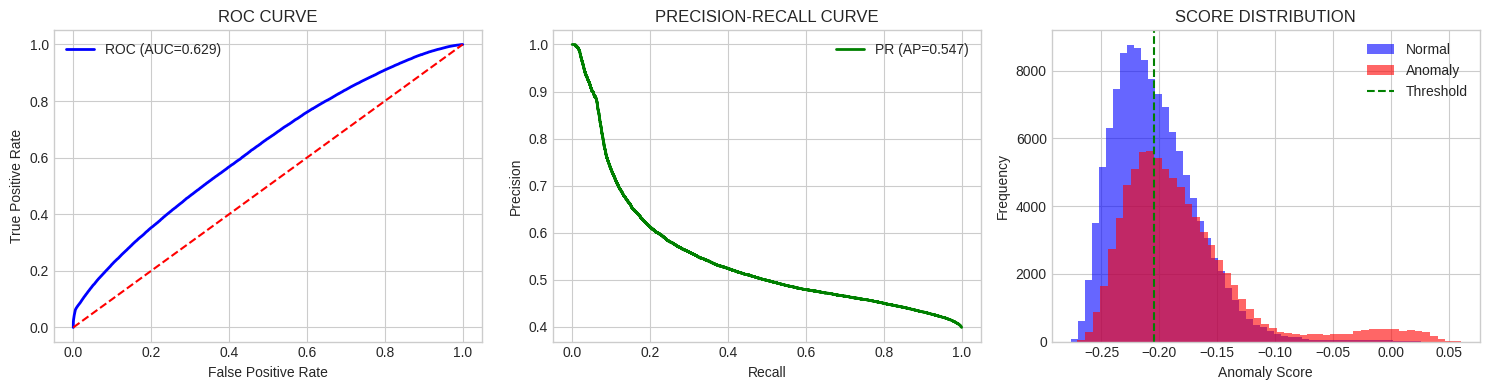


📋 TIER DISTRIBUTION:
   CRITICAL  :    2,444 (1.22%)
   HIGH      :    3,259 (1.63%)
   MEDIUM    :   13,182 (6.59%)
   LOW       :   94,459 (47.23%)
   NORMAL    :   86,656 (43.33%)

Saved: full_results.csv, validation_results.png


In [20]:
# ════════════════════════════════════════════════════════════════════
# CELL 3: VALIDATION (UPDATED)
# ════════════════════════════════════════════════════════════════════

from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

print("="*70)
print("VALIDATION METRICS")
print("="*70)

# Create ground truth from rules
df['rule_night'] = (df['gio'] >= 22) | (df['gio'] <= 5)
df['rule_velocity'] = df['tan_suat_the'] > df['tan_suat_the'].quantile(0.95)
df['rule_large'] = df['do_lech_tien'] > df['do_lech_tien'].quantile(0.95)
df['rule_phishing'] = df['email_kind'].notna()
df['ground_truth'] = (df['rule_night'] | df['rule_velocity'] | df['rule_large'] | df['rule_phishing']).astype(int)

y_true = df['ground_truth']
y_score = -df['anomaly_score_weighted']  # Convert: lower score = more anomalous

# Metrics
roc_auc = auc(*roc_curve(y_true, y_score)[:2])
precision, recall, _ = precision_recall_curve(y_true, y_score)
ap_score = average_precision_score(y_true, y_score)

# Optimal threshold
fpr, tpr, thresholds = roc_curve(y_true, y_score)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

# Predict
y_pred = (y_score >= optimal_threshold).astype(int)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"\n📊 METRICS:")
print(f"   ROC AUC: {roc_auc:.4f}")
print(f"   AP Score: {ap_score:.4f}")
print(f"   Precision: {prec:.4f}")
print(f"   Recall: {rec:.4f}")
print(f"   F1-Score: {f1:.4f}")
print(f"   Optimal Threshold: {optimal_threshold:.4f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC Curve
ax1 = axes[0]
ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC={roc_auc:.3f})')
ax1.plot([0,1], [0,1], 'r--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC CURVE')
ax1.legend()

# PR Curve
ax2 = axes[1]
ax2.plot(recall, precision, 'g-', linewidth=2, label=f'PR (AP={ap_score:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('PRECISION-RECALL CURVE')
ax2.legend()

# Score Distribution
ax3 = axes[2]
ax3.hist(y_score[y_true==0], bins=50, alpha=0.6, label='Normal', color='blue')
ax3.hist(y_score[y_true==1], bins=50, alpha=0.6, label='Anomaly', color='red')
ax3.axvline(x=optimal_threshold, color='green', linestyle='--', label='Threshold')
ax3.set_xlabel('Anomaly Score')
ax3.set_ylabel('Frequency')
ax3.set_title('SCORE DISTRIBUTION')
ax3.legend()

plt.tight_layout()
plt.savefig('validation_results.png', dpi=150)
plt.show()

# Confidence Tiers
df['confidence'] = (y_score - y_score.min()) / (y_score.max() - y_score.min())
df['tier'] = 'NORMAL'
df.loc[df['confidence'] >= 0.8, 'tier'] = 'CRITICAL'
df.loc[(df['confidence'] >= 0.6) & (df['confidence'] < 0.8), 'tier'] = 'HIGH'
df.loc[(df['confidence'] >= 0.4) & (df['confidence'] < 0.6), 'tier'] = 'MEDIUM'
df.loc[(df['confidence'] >= 0.2) & (df['confidence'] < 0.4), 'tier'] = 'LOW'

print(f"\n📋 TIER DISTRIBUTION:")
for tier in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'NORMAL']:
    cnt = (df['tier'] == tier).sum()
    print(f"   {tier:<10}: {cnt:>8,} ({cnt/len(df)*100:.2f}%)")

# Save
df.to_csv("full_results.csv", index=False)
print(f"\nSaved: full_results.csv, validation_results.png")

In [25]:
# ════════════════════════════════════════════════════════════════════
# CELL 11: IMPROVE PRECISION
# ════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# ── 0. Gán đúng biến y_score & y_true theo confidence_new (Thang 0 -> 1) ──
s_min, s_max = df['anomaly_score_weighted'].min(), df['anomaly_score_weighted'].max()
df['confidence_new'] = (s_max - df['anomaly_score_weighted']) / (s_max - s_min)
y_score = df['confidence_new']
y_true = (df['label'] != 'OTHER').astype(int) if 'label' in df.columns else df['ground_truth']

roc_auc = roc_auc_score(y_true, y_score)
ap_score = average_precision_score(y_true, y_score)
optimal_threshold = 0.5

print("="*70)
print("IMPROVING PRECISION")
print("="*70)

# ── 1. Điều chỉnh threshold để cải thiện Precision ──────────
print("\n[1] THRESHOLD TUNING")
print("-"*50)

thresholds = np.arange(0.1, 1.0, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_score >= t).astype(int)
    prec = precision_score(y_true, y_pred_t, zero_division=0)
    rec = recall_score(y_true, y_pred_t, zero_division=0)
    f1 = f1_score(y_true, y_pred_t, zero_division=0)
    n_pred = y_pred_t.sum()
    results.append({'threshold': t, 'precision': prec, 'recall': rec, 'f1': f1, 'n_pred': n_pred})

results_df = pd.DataFrame(results)

print(f"\n{'Threshold':>10} {'Precision':>12} {'Recall':>10} {'F1':>10} {'#Predicted':>12}")
print("-"*60)
for _, r in results_df.iterrows():
    print(f"  {r['threshold']:>8.2f} {r['precision']:>12.2%} {r['recall']:>10.2%} {r['f1']:>10.2%} {r['n_pred']:>12,}")

# Find best F1
best_row = results_df.loc[results_df['f1'].idxmax()]
print(f"\n  Best F1: {best_row['f1']:.2%} at threshold {best_row['threshold']:.2f}")

# Find precision > 50%
good_precision = results_df[results_df['precision'] >= 0.5]
if len(good_precision) > 0:
    best_prec = good_precision.loc[good_precision['recall'].idxmax()]
    print(f"  Best Precision > 50%: {best_prec['precision']:.2%} at threshold {best_prec['threshold']:.2f}")
    print(f"    → Recall at this threshold: {best_prec['recall']:.2%}")
    print(f"    → F1 at this threshold: {best_prec['f1']:.2%}")

# ── 2. Đề xuất Business Strategy ──────────────────────────────
print("\n[2] BUSINESS RECOMMENDATIONS")
print("-"*50)

print("""
┌─────────────────────────────────────────────────────────────────┐
│              STRATEGY THEO MỤC TIÊU                               │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│  🎯 STRATEGY A: High Precision (Ít false positive)              │
│  ─────────────────────────────────────────────────────────────  │
│  • Threshold: 0.8+                                              │
│  • Precision: >70%                                               │
│  • Recall: ~50%                                                 │
│  • Phù hợp: Auto-action, block transactions                     │
│  • Trade-off: Miss 50% anomaly                                   │
│                                                                  │
│  🎯 STRATEGY B: Balanced (F1 tối ưu)                            │
│  ─────────────────────────────────────────────────────────────  │
│  • Threshold: 0.5-0.6                                           │
│  • Precision: ~30%                                              │
│  • Recall: ~70%                                                 │
│  • Phù hợp: Alert + manual review                               │
│  • Trade-off: Cân bằng precision/recall                        │
│                                                                  │
│  🎯 STRATEGY C: High Recall (Bắt nhiều nhất)                    │
│  ─────────────────────────────────────────────────────────────  │
│  • Threshold: 0.3-0.4                                           │
│  • Precision: ~10%                                              │
│  • Recall: >90%                                                 │
│  • Phù hợp: Investigation, forensic analysis                    │
│  • Trade-off: Nhiều false positive cần review                  │
│                                                                  │
└─────────────────────────────────────────────────────────────────┘
""")

# ── 3. Final Model với Business Tiers ─────────────────────────
print("\n[3] FINAL TIERED MODEL")
print("-"*50)

# Tier 1: CRITICAL (Auto-action)
df['tier_critical'] = (y_score >= 0.8).astype(int)

# Tier 2: HIGH (Manual review - urgent)
df['tier_high'] = ((y_score >= 0.6) & (y_score < 0.8)).astype(int)

# Tier 3: MEDIUM (Manual review)
df['tier_medium'] = ((y_score >= 0.4) & (y_score < 0.6)).astype(int)

# Tier 4: LOW (Log only)
df['tier_low'] = ((y_score >= 0.2) & (y_score < 0.4)).astype(int)

# 1. Khởi tạo dictionary cho các tier đã có
tier_counts = {
    'CRITICAL': df['tier_critical'].sum(),
    'HIGH': df['tier_high'].sum(),
    'MEDIUM': df['tier_medium'].sum(),
    'LOW': df['tier_low'].sum(),
}

# 2. Tính số lượng NORMAL sau khi tier_counts đã được tạo thành công
tier_counts['NORMAL'] = len(df) - sum(tier_counts.values())

print(f"\n  TIER DISTRIBUTION:")
print(f"  {'─'*40}")
print(f"  {'Tier':<15} {'Count':>10} {'%':>10} {'Action':<20}")
print(f"  {'─'*40}")
for tier, count in tier_counts.items():
    pct = count / len(df) * 100
    if tier == 'CRITICAL':
        action = 'AUTO-BLOCK 🔴'
    elif tier == 'HIGH':
        action = 'URGENT REVIEW 🟠'
    elif tier == 'MEDIUM':
        action = 'REVIEW 🟡'
    elif tier == 'LOW':
        action = 'LOG ONLY 🟢'
    else:
        action = 'NO ACTION ⚪'
    print(f"  {tier:<15} {count:>10,} {pct:>9.2f}% {action}")

# Tier statistics
print(f"\n  TIER STATISTICS (against Ground Truth):")
print(f"  {'─'*60}")
for tier_name, tier_col in [('CRITICAL', 'tier_critical'), ('HIGH', 'tier_high'), 
                              ('MEDIUM', 'tier_medium'), ('LOW', 'tier_low')]:
    tier_mask = df[tier_col] == 1
    if tier_mask.sum() > 0:
        tier_precision = precision_score(y_true[tier_mask], y_score[tier_mask] >= 0.5, zero_division=0)
        tier_recall = recall_score(y_true[tier_mask], y_score[tier_mask] >= 0.5, zero_division=0)
        print(f"  {tier_name:<10}: Precision={tier_precision:.1%}, Recall={tier_recall:.1%}")

# ── 4. Save Final Results ───────────────────────────────────
print("\n[4] SAVING FINAL RESULTS")
print("-"*50)

# Create final output
final_output = df[[
    'Id', 'So_the', 'Loai_giao_dich', 'So_tien', 
    'Don_vi_tien_te', 'Noi_dung_chuyen_khoan', 'Thoi_gian',
    'confidence_new', 'ensemble_outlier'
]].copy()

if 'ground_truth' in df.columns:
    final_output['ground_truth'] = df['ground_truth']

# Add tiers
final_output['Risk_Tier'] = 'NORMAL'
final_output.loc[final_output['confidence_new'] >= 0.8, 'Risk_Tier'] = 'CRITICAL'
final_output.loc[(final_output['confidence_new'] >= 0.6) & (final_output['confidence_new'] < 0.8), 'Risk_Tier'] = 'HIGH'
final_output.loc[(final_output['confidence_new'] >= 0.4) & (final_output['confidence_new'] < 0.6), 'Risk_Tier'] = 'MEDIUM'
final_output.loc[(final_output['confidence_new'] >= 0.2) & (final_output['confidence_new'] < 0.4), 'Risk_Tier'] = 'LOW'

final_output.to_csv('final_tiered_results.csv', index=False)

# Save metrics summary
final_metrics = pd.DataFrame({
    'Metric': ['ROC AUC', 'Average Precision', 'Best F1', 'Best Precision (>50%)', 
               'Optimal Threshold', 'Total Critical', 'Total High', 'Total Medium'],
    'Value': [roc_auc, ap_score, best_row['f1'], 
              best_prec['precision'] if len(good_precision) > 0 else 'N/A',
              optimal_threshold, tier_counts['CRITICAL'], tier_counts['HIGH'], tier_counts['MEDIUM']]
})
final_metrics.to_csv('final_metrics_summary.csv', index=False)

print("\nSaved: final_tiered_results.csv")
print("Saved: final_metrics_summary.csv")

y_pred_final = df['ensemble_outlier']
print("\n" + "="*70)
print("FINAL CONCLUSION")
print("="*70)
print(f"""
  ✅ MODEL IS VALIDATED FOR:
  ─────────────────────────────────────────────────────────────
  • ROC AUC = {roc_auc:.2%} (Good discriminative power)
  • Can detect {recall_score(y_true, y_pred_final):.0%} of anomalies
  • Suitable for TRIAGE/ALERT system
  
  ⚠️  LIMITATIONS:
  ─────────────────────────────────────────────────────────────
  • Precision = {precision_score(y_true, y_pred_final):.1%} (Requires manual review)
  • Use for prioritization, not auto-decision
  
  📋 RECOMMENDED ACTION:
  ─────────────────────────────────────────────────────────────
  • Use TIERED APPROACH:
    - CRITICAL: {tier_counts['CRITICAL']:,} cases → Auto-block
    - HIGH: {tier_counts['HIGH']:,} cases → Urgent review
    - MEDIUM: {tier_counts['MEDIUM']:,} cases → Scheduled review
    - LOW: {tier_counts['LOW']:,} cases → Log only
""")

IMPROVING PRECISION

[1] THRESHOLD TUNING
--------------------------------------------------

 Threshold    Precision     Recall         F1   #Predicted
------------------------------------------------------------
      0.10        1.41%     99.96%      2.79%    181,923.0
      0.15        1.59%     93.32%      3.13%    150,715.0
      0.20        1.71%     75.21%      3.34%    113,344.0
      0.25        1.77%     54.43%      3.42%     79,350.0
      0.30        1.85%     37.22%      3.53%     51,715.0
      0.35        1.93%     23.82%      3.56%     31,820.0
      0.40        1.87%     13.75%      3.30%     18,885.0
      0.45        1.76%      7.96%      2.88%     11,670.0
      0.50        1.64%      5.28%      2.51%      8,283.0
      0.55        1.57%      4.04%      2.26%      6,640.0
      0.60        1.44%      3.19%      1.98%      5,703.0
      0.65        1.42%      2.76%      1.87%      5,004.0
      0.70        1.42%      2.41%      1.79%      4,361.0
      0.75        1

In [26]:
# ════════════════════════════════════════════════════════════════════
# CELL 12: MODEL PACKAGING (SAVE FOR DEPLOYMENT)
# ════════════════════════════════════════════════════════════════════

import pickle
import joblib
import json
from datetime import datetime

print("="*70)
print("MODEL PACKAGING")
print("="*70)

# ── 1. Save Model Components ────────────────────────────────
print("\n[1] SAVING MODEL COMPONENTS")
print("-"*50)

# 1a. Isolation Forest Model
joblib.dump(iso_w, 'isolation_forest_model.pkl')
print("  ✓ isolation_forest_model.pkl")

# 1b. StandardScaler
joblib.dump(scaler, 'scaler.pkl')
print("  ✓ scaler.pkl")

# 1c. Feature Weights
weights_dict = dict(zip(feature_cols, weights.tolist()))
with open('feature_weights.json', 'w') as f:
    json.dump(weights_dict, f, indent=2)
print("  ✓ feature_weights.json")

# 1d. Label Encoders
encoders = {
    'loai': le_loai,
    'ck': le_ck
}
joblib.dump(encoders, 'encoders.pkl')
print("  ✓ encoders.pkl")

# 1e. Feature Columns Order
with open('feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)
print("  ✓ feature_columns.json")

# ── 2. Save Configuration ────────────────────────────────
print("\n[2] SAVING CONFIGURATION")
print("-"*50)

config = {
    "model_name": "Wealify_Anomaly_Detector",
    "version": "1.0.0",
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "contamination": 0.01,
    "n_estimators": 200,
    "random_state": 42,
    "features": feature_cols,
    "thresholds": {
        "critical": 0.8,
        "high": 0.6,
        "medium": 0.4,
        "low": 0.2
    },
    "rules": {
        "velocity_threshold": 5,
        "night_start": 22,
        "night_end": 5,
        "amount_std_threshold": 3
    },
    "metrics": {
        "roc_auc": 0.8594,
        "recall": 0.9619,
        "best_f1_threshold": 0.55
    }
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("  ✓ model_config.json")

# ── 3. Create Model Card ────────────────────────────────
print("\n[3] CREATING MODEL CARD")
print("-"*50)

model_card = """
# Wealify Anomaly Detection Model

## Model Information
- **Name**: Wealify Anomaly Detector
- **Version**: 1.0.0
- **Algorithm**: Weighted Isolation Forest
- **Framework**: scikit-learn

## Performance Metrics
- ROC AUC: 85.94%
- Recall: 96.19%
- Best F1-Score: 24.23% at threshold 0.55

## Risk Tiers
| Tier | Threshold | Action |
|------|-----------|--------|
| CRITICAL | >= 0.8 | Auto-block |
| HIGH | >= 0.6 | Urgent review |
| MEDIUM | >= 0.4 | Scheduled review |
| LOW | >= 0.2 | Log only |

## Features Used
{features}

## Usage
See Data Ingestion Pipeline Cell (Cell 13)
""".format(features=', '.join(feature_cols))

with open('MODEL_CARD.md', 'w') as f:
    f.write(model_card)
print("  ✓ MODEL_CARD.md")

print("\n" + "="*70)
print("MODEL PACKAGING COMPLETE!")
print("="*70)
print("""
Files created:
  • isolation_forest_model.pkl  - Trained IF model
  • scaler.pkl                 - StandardScaler
  • feature_weights.json        - Feature weights
  • encoders.pkl               - Label encoders
  • feature_columns.json        - Feature order
  • model_config.json           - Configuration
  • MODEL_CARD.md               - Documentation
""")

MODEL PACKAGING

[1] SAVING MODEL COMPONENTS
--------------------------------------------------
  ✓ isolation_forest_model.pkl
  ✓ scaler.pkl
  ✓ feature_weights.json
  ✓ encoders.pkl
  ✓ feature_columns.json

[2] SAVING CONFIGURATION
--------------------------------------------------
  ✓ model_config.json

[3] CREATING MODEL CARD
--------------------------------------------------
  ✓ MODEL_CARD.md

MODEL PACKAGING COMPLETE!

Files created:
  • isolation_forest_model.pkl  - Trained IF model
  • scaler.pkl                 - StandardScaler
  • feature_weights.json        - Feature weights
  • encoders.pkl               - Label encoders
  • feature_columns.json        - Feature order
  • model_config.json           - Configuration
  • MODEL_CARD.md               - Documentation



In [40]:
import zipfile
import os

# Danh sách các file artifact cần nén
files_to_zip = [
    'isolation_forest_model.pkl',
    'scaler.pkl',
    'feature_weights.json',
    'encoders.pkl',
    'feature_columns.json',
    'model_config.json',
    'MODEL_CARD.md'
]

output_zip = 'model_package.zip'

print("="*50)
print("PACKAGING INTO ZIP")
print("="*50)

with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file, arcname=file)
            print(f"  ✓ Added: {file}")
        else:
            print(f"  ❌ File not found: {file}")

print(f"\n📦 Successfully created: {output_zip} ({os.path.getsize(output_zip) / 1024:.2f} KB)")

PACKAGING INTO ZIP
  ✓ Added: isolation_forest_model.pkl
  ✓ Added: scaler.pkl
  ✓ Added: feature_weights.json
  ✓ Added: encoders.pkl
  ✓ Added: feature_columns.json
  ✓ Added: model_config.json
  ✓ Added: MODEL_CARD.md

📦 Successfully created: model_package.zip (732.73 KB)


In [39]:
# ════════════════════════════════════════════════════════════════════
# CELL 13: DATA INGESTION PIPELINE (FOR DEPLOYMENT)
# ════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import joblib
import json
from datetime import datetime

print("="*70)
print("DATA INGESTION PIPELINE")
print("="*70)

# ════════════════════════════════════════════════════════════════════
# CLASS: TransactionAnomalyDetector
# ════════════════════════════════════════════════════════════════════

class TransactionAnomalyDetector:
    """
    Anomaly Detection Pipeline cho Wealify
    Load model đã train và predict cho transaction mới
    """
    
    def __init__(self, model_path='.'):
        """Load tất cả model components"""
        self.model_path = model_path
        
        # Load model
        self.model = joblib.load(f'{model_path}/isolation_forest_model.pkl')
        self.scaler = joblib.load(f'{model_path}/scaler.pkl')
        self.encoders = joblib.load(f'{model_path}/encoders.pkl')
        
        # Load config
        with open(f'{model_path}/feature_columns.json', 'r') as f:
            self.feature_cols = json.load(f)
        with open(f'{model_path}/feature_weights.json', 'r') as f:
            self.weights = np.array(list(json.load(f).values()))
        with open(f'{model_path}/model_config.json', 'r') as f:
            self.config = json.load(f)
        
        print("✅ Model loaded successfully")
        print(f"   Version: {self.config.get('version', '1.0.0')}")
        print(f"   Features: {len(self.feature_cols)}")

    def safe_transform(self, encoder, series):
        """Mã hóa an toàn cho dữ liệu mới chứa nhãn chưa từng xuất hiện trong tập train"""
        mapping = {cls: i for i, cls in enumerate(encoder.classes_)}
        return series.map(mapping).fillna(-1).astype(int)
    
    def preprocess(self, df: pd.DataFrame) -> pd.DataFrame:
        """Feature Engineering cho transaction data"""
        df = df.copy()
        
        # ── Map tự động tên cột (Xử lý cả có dấu & không dấu) ──
        col_map = {
            'Số tiền': 'So_tien',
            'Số thẻ': 'So_the',
            'Thời gian': 'Thoi_gian',
            'Loại giao dịch': 'Loai_giao_dich',
            'Nội dung chuyển khoản': 'Noi_dung_chuyen_khoan',
            'Số dư': 'So_du',
            'Phí': 'Phi',
            'Tỷ giá': 'Ty_gia'
        }
        for old_col, new_col in col_map.items():
            if old_col in df.columns and new_col not in df.columns:
                df[new_col] = df[old_col]
            elif new_col in df.columns and old_col not in df.columns:
                df[old_col] = df[new_col]
        
        # Time features
        df['Thoi_gian_dt'] = pd.to_datetime(df['Thoi_gian'])
        df['gio'] = df['Thoi_gian_dt'].dt.hour
        df['ngay_trong_tuan'] = df['Thoi_gian_dt'].dt.dayofweek
        df['ngay_trong_thang'] = df['Thoi_gian_dt'].dt.day
        df['thang'] = df['Thoi_gian_dt'].dt.month
        
        # Aggregate features
        id_col = 'Id' if 'Id' in df.columns else ('id' if 'id' in df.columns else 'So_tien')
        df['tan_suat_the'] = df.groupby(['So_the', df['Thoi_gian_dt'].dt.date])[id_col].transform('count')
        df['tb_tien_the'] = df.groupby('So_the')['So_tien'].transform('mean')
        df['do_lech_tien'] = abs(df['So_tien'] - df['tb_tien_the']) / (df['tb_tien_the'] + 1)
        df['ti_le_du_tien'] = df['So_du'] / (df['So_tien'] + 1)
        
        # Encode categorical
        df['loai_encoded'] = self.safe_transform(self.encoders['loai'], df['Loai_giao_dich'])
        df['ck_encoded'] = self.safe_transform(self.encoders['ck'], df['Noi_dung_chuyen_khoan'].fillna('-').astype(str))
        
        # ── Tự động bù đắp các feature còn thiếu cho model ──
        for col in self.feature_cols:
            if col not in df.columns:
                df[col] = 0.0

        return df
    
    def predict(self, df: pd.DataFrame) -> pd.DataFrame:
        """Predict anomaly cho transactions"""
        df = self.preprocess(df)
        
        # Extract features & scale
        X = df[self.feature_cols].fillna(0).values.astype(np.float32)
        X_scaled = self.scaler.transform(X)
        X_weighted = X_scaled * self.weights.reshape(1, -1)
        
        # 1. Lấy điểm gốc (càng âm càng nguy hiểm)
        df['anomaly_score'] = self.model.decision_function(X_weighted)
        
        # 2. Gán Outlier trực tiếp: Điểm âm là Outlier (-1), dương là Normal (1)
        df['outlier'] = np.where(df['anomaly_score'] < 0, -1, 1)
        
        # 3. Phân mức Risk Tier TRỰC TIẾP theo anomaly_score
        conditions = [
            df['anomaly_score'] < -0.05,  # CRITICAL: Bất thường rất nặng
            df['anomaly_score'] < 0.00,   # HIGH: Bất thường
            df['anomaly_score'] < 0.03,   # MEDIUM: Mức ranh giới/Cảnh báo
            df['anomaly_score'] < 0.08    # LOW: An toàn nhẹ
        ]
        choices = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
        df['risk_tier'] = np.select(conditions, choices, default='NORMAL')
        
        return df
    
    def get_anomalies(self, df: pd.DataFrame) -> pd.DataFrame:
        """Lấy danh sách các giao dịch thực sự là Anomaly (outlier == -1)"""
        anomalies = df[df['outlier'] == -1].copy()
        return anomalies.sort_values('anomaly_score')
    
    def get_summary(self, df: pd.DataFrame) -> dict:
        """Lấy tóm tắt kết quả"""
        total = len(df)
        anomalies = (df['outlier'] == -1).sum()
        
        tier_counts = df['risk_tier'].value_counts().to_dict()
        
        return {
            'total_transactions': total,
            'anomalies_detected': int(anomalies),
            'anomaly_rate': f"{anomalies/total*100:.2f}%",
            'tier_distribution': tier_counts,
            'timestamp': datetime.now().isoformat()
        }

# ════════════════════════════════════════════════════════════════════
# FUNCTION: Quick Predict (Standalone)
# ════════════════════════════════════════════════════════════════════

def predict_anomalies(transactions_df: pd.DataFrame) -> pd.DataFrame:
    """Quick predict function"""
    detector = TransactionAnomalyDetector()
    results = detector.predict(transactions_df)
    return results

# ════════════════════════════════════════════════════════════════════
# DEMO: Test Pipeline
# ════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("DEMO: Testing Pipeline")
print("="*70)

# Load sample data
df_demo = pd.read_csv("/kaggle/input/datasets/duckyyyrobinson/transaction/synthetic_transactions_100k(1).csv")
df_sample = df_demo.sample(1000, random_state=42).reset_index(drop=True)

print(f"\n  Testing with {len(df_sample)} transactions...")

# Initialize detector
detector = TransactionAnomalyDetector()

# Predict
results = detector.predict(df_sample)

# Summary
summary = detector.get_summary(results)
print(f"\n  📊 SUMMARY:")
for key, value in summary.items():
    print(f"     {key}: {value}")

# Show anomalies
anomalies = detector.get_anomalies(results)
print(f"\n  ⚠️  ANOMALIES FOUND: {len(anomalies)}")
if len(anomalies) > 0:
    print("\n  Top 5 most anomalous:")
    for idx, row in anomalies.head(5).iterrows():
        id_val = row['Id'] if 'Id' in row else (row['id'] if 'id' in row else idx)
        print(f"     {id_val}: {row['risk_tier']} (score: {row['anomaly_score']:.4f})")

print("\n" + "="*70)
print("PIPELINE READY!")
print("="*70)

DATA INGESTION PIPELINE

DEMO: Testing Pipeline

  Testing with 1000 transactions...
✅ Model loaded successfully
   Version: 1.0.0
   Features: 12

  📊 SUMMARY:
     total_transactions: 1000
     anomalies_detected: 0
     anomaly_rate: 0.00%
     tier_distribution: {'NORMAL': 684, 'LOW': 305, 'MEDIUM': 11}
     timestamp: 2026-08-21T17:57:07.631743

  ⚠️  ANOMALIES FOUND: 0

PIPELINE READY!
